# PCA Dimensions Classifier

Trains a logistic regression classifier on the principal components of the
raw `SelfAttention.o` activation vectors to detect hallucination.

Key questions answered:
- How accurately can we detect hallucination using just PC1 and PC2?
- How does accuracy change as we add more components?
- What does the decision boundary look like in PCA space?

Data acquisition is identical to `pca_scatter_from_mongo.ipynb`.

## Cell 1 — Imports

In [25]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull

from neuralsignal.backend.ns_backend import NSBackend

print("Imports OK")

Imports OK


## Cell 2 — Config

In [26]:
APPLICATION_NAME     = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

GROUP_SIZE   = 50
LAYER_INDEX  = -2    # penultimate SelfAttention.o layer
N_COMPONENTS = 20    # fit up to 20 PCA components
CV_FOLDS     = 5     # stratified k-fold cross-validation
RANDOM_STATE = 42

# Correct prediction: model output agrees with ground truth
# Hallucinated:       model output disagrees with ground truth
# Both ground_truth values (0 and 1) are included in each group.
FILTER_CORRECT = {"$or": [
    {"ground_truth": "0", "decoded_output": {"$regex": "^Fal"}},
    {"ground_truth": "1", "decoded_output": {"$regex": "^True"}},
]}
FILTER_HALLUCINATED = {"$or": [
    {"ground_truth": "0", "decoded_output": {"$regex": "^True"}},
    {"ground_truth": "1", "decoded_output": {"$regex": "^Fal"}},
]}

## Cell 3 — Connect to backend & load scan groups

In [27]:
import tempfile
from neuralsignal.core.modules.neuralsignal_config import sdk_config

backend_cfg = sdk_config.get_backend_config()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def load_group(be, mongo_filter, n):
    cursor = be.query(mongo_filter).limit(n)
    scans = []
    for doc in cursor:
        try:
            scans.append(be.deserialize_scan(doc))
        except Exception as e:
            print(f"  skipping {doc.get('_id')}: {e}")
    return scans

print("Loading correct group ...")
group_correct = load_group(be, FILTER_CORRECT, GROUP_SIZE)
print(f"  loaded {len(group_correct)} scans")

print("Loading hallucinated group ...")
group_hallucinated = load_group(be, FILTER_HALLUCINATED, GROUP_SIZE)
print(f"  loaded {len(group_hallucinated)} scans")

Loading correct group ...
  loaded 50 scans
Loading hallucinated group ...
  loaded 50 scans


## Cell 4 — Extract activation vectors & build label array

In [28]:
def extract_layer_vector(scan, layer_index):
    layer_id_to_name = scan["layer_id_to_name"]
    sa_layers = [
        lid for lid in scan["layer_order"]
        if "SelfAttention.o" in layer_id_to_name[lid]
    ]
    if not sa_layers:
        raise ValueError("No SelfAttention.o layers found.")
    lid = sa_layers[layer_index]
    tensor = scan["outputs"][lid]
    return tensor[-1, :].float(), layer_id_to_name[lid]

def build_matrix(scans, layer_index, expected_dim=None):
    vectors, skipped = [], 0
    for scan in scans:
        try:
            vec, _ = extract_layer_vector(scan, layer_index)
            if expected_dim is not None and vec.shape[0] != expected_dim:
                skipped += 1
                continue
            vectors.append(vec)
        except Exception:
            skipped += 1
    if skipped:
        print(f"  skipped {skipped} scans")
    return torch.stack(vectors)

vecs_correct      = build_matrix(group_correct,      LAYER_INDEX)
vecs_hallucinated = build_matrix(group_hallucinated, LAYER_INDEX,
                                 expected_dim=vecs_correct.shape[1])

_, layer_name = extract_layer_vector(group_correct[0], LAYER_INDEX)
print(f"Layer       : {layer_name}")
print(f"Correct     : {vecs_correct.shape}")
print(f"Hallucinated: {vecs_hallucinated.shape}")

# 0 = correct prediction, 1 = hallucinated (model output disagrees with ground truth)
X_raw = np.vstack([vecs_correct.numpy(), vecs_hallucinated.numpy()])
y     = np.array([0] * len(vecs_correct) + [1] * len(vecs_hallucinated))
print(f"\nX_raw : {X_raw.shape}")
print(f"y     : {y.shape}  ({(y==0).sum()} correct, {(y==1).sum()} hallucinated)")

Layer       : decoder.T5Block.T5LayerSelfAttention.SelfAttention.o
Correct     : torch.Size([50, 1024])
Hallucinated: torch.Size([50, 1024])

X_raw : (100, 1024)
y     : (100,)  (50 correct, 50 hallucinated)


## Cell 5 — Fit PCA on combined data

In [29]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_raw)   # (N, N_COMPONENTS)

var = pca.explained_variance_ratio_ * 100
print("Explained variance:")
for i, v in enumerate(var):
    cumulative = var[:i+1].sum()
    print(f"  PC{i+1:>2}: {v:5.1f}%   cumulative: {cumulative:5.1f}%")

Explained variance:
  PC 1:  69.2%   cumulative:  69.2%
  PC 2:  14.1%   cumulative:  83.3%
  PC 3:   5.6%   cumulative:  88.9%
  PC 4:   1.3%   cumulative:  90.2%
  PC 5:   0.9%   cumulative:  91.1%
  PC 6:   0.6%   cumulative:  91.7%
  PC 7:   0.6%   cumulative:  92.3%
  PC 8:   0.5%   cumulative:  92.8%
  PC 9:   0.4%   cumulative:  93.3%
  PC10:   0.4%   cumulative:  93.7%
  PC11:   0.4%   cumulative:  94.0%
  PC12:   0.3%   cumulative:  94.4%
  PC13:   0.3%   cumulative:  94.7%
  PC14:   0.3%   cumulative:  95.0%
  PC15:   0.3%   cumulative:  95.2%
  PC16:   0.2%   cumulative:  95.5%
  PC17:   0.2%   cumulative:  95.7%
  PC18:   0.2%   cumulative:  95.9%
  PC19:   0.2%   cumulative:  96.1%
  PC20:   0.2%   cumulative:  96.3%


## Cell 6 — Cross-validated AUC vs number of components

For each k from 1 to N_COMPONENTS, a **Pipeline** (PCA → LogisticRegression) is trained
and evaluated with 5-fold stratified cross-validation.  PCA is re-fit on each training fold
so no test-fold information leaks into the components — fixing the data-leakage bug that
would otherwise inflate AUC when PCA is fit on all data before CV.

In [30]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

aucs, accs, auc_stds, acc_stds = [], [], [], []

for k in range(1, N_COMPONENTS + 1):
    # PCA is inside the pipeline so it is re-fit on each training fold only.
    # X_raw (not the pre-transformed X_pca) is the input to avoid leakage.
    pipe = Pipeline([
        ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    results = cross_validate(pipe, X_raw, y, cv=cv,
                             scoring=["roc_auc", "accuracy"],
                             return_train_score=False)
    aucs.append(results["test_roc_auc"].mean())
    auc_stds.append(results["test_roc_auc"].std())
    accs.append(results["test_accuracy"].mean())
    acc_stds.append(results["test_accuracy"].std())
    print(f"  k={k:>2}  AUC={aucs[-1]:.4f} ± {auc_stds[-1]:.4f}   Acc={accs[-1]:.4f} ± {acc_stds[-1]:.4f}")

aucs     = np.array(aucs)
auc_stds = np.array(auc_stds)
accs     = np.array(accs)
acc_stds = np.array(acc_stds)

best_k_auc = np.argmax(aucs) + 1
print(f"\nBest AUC : {aucs.max():.4f} at k={best_k_auc}")
print(f"PC1+PC2  : AUC={aucs[1]:.4f}   Accuracy={accs[1]:.4f}")

  k= 1  AUC=0.7000 ± 0.1667   Acc=0.6300 ± 0.0748
  k= 2  AUC=0.6820 ± 0.1653   Acc=0.6300 ± 0.0748
  k= 3  AUC=0.7700 ± 0.1083   Acc=0.6900 ± 0.0735
  k= 4  AUC=0.8000 ± 0.1073   Acc=0.7900 ± 0.0583
  k= 5  AUC=0.8300 ± 0.0988   Acc=0.7900 ± 0.0583
  k= 6  AUC=0.8440 ± 0.1025   Acc=0.7800 ± 0.0678
  k= 7  AUC=0.8320 ± 0.0937   Acc=0.7700 ± 0.0510
  k= 8  AUC=0.8340 ± 0.1007   Acc=0.7300 ± 0.0400
  k= 9  AUC=0.8180 ± 0.1134   Acc=0.7700 ± 0.0245
  k=10  AUC=0.8320 ± 0.0757   Acc=0.7600 ± 0.0374
  k=11  AUC=0.8160 ± 0.0840   Acc=0.7400 ± 0.0374
  k=12  AUC=0.8400 ± 0.1126   Acc=0.7900 ± 0.0860
  k=13  AUC=0.8340 ± 0.1141   Acc=0.7700 ± 0.1122
  k=14  AUC=0.8260 ± 0.1037   Acc=0.7700 ± 0.1122
  k=15  AUC=0.8260 ± 0.1109   Acc=0.7700 ± 0.1470
  k=16  AUC=0.8220 ± 0.1129   Acc=0.7700 ± 0.1470
  k=17  AUC=0.8280 ± 0.1162   Acc=0.7500 ± 0.1449
  k=18  AUC=0.8240 ± 0.1211   Acc=0.7300 ± 0.0927
  k=19  AUC=0.8100 ± 0.1086   Acc=0.7400 ± 0.1020
  k=20  AUC=0.8260 ± 0.0954   Acc=0.7600 ± 0.0860


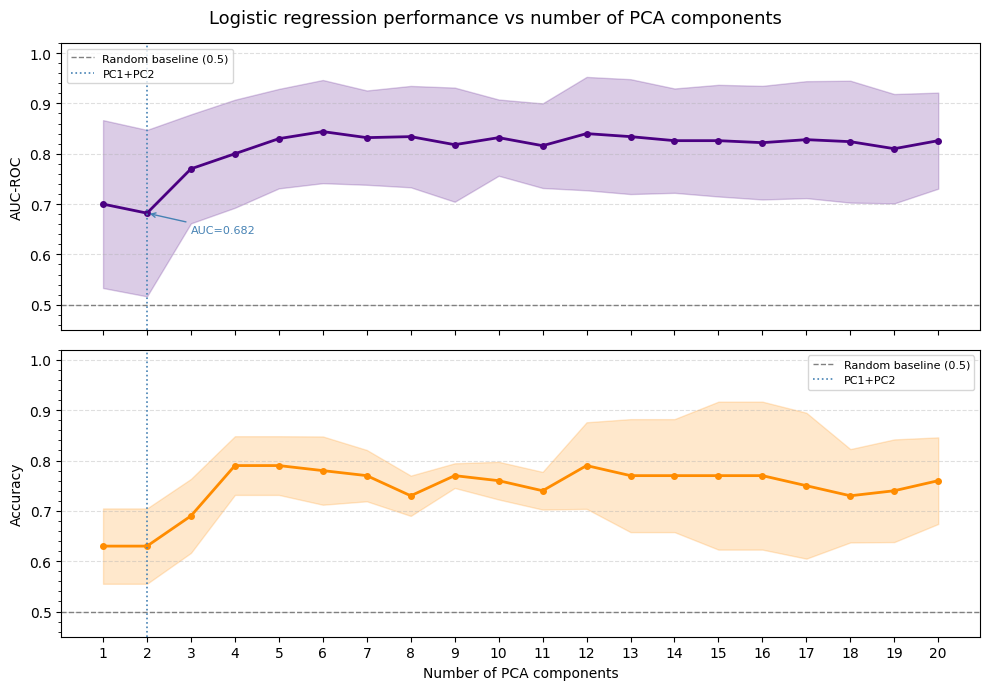

In [31]:
k_range = np.arange(1, N_COMPONENTS + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Logistic regression performance vs number of PCA components", fontsize=13)

# ── AUC ──────────────────────────────────────────────────────────────────────
ax1.plot(k_range, aucs, color="indigo", linewidth=2, marker="o", markersize=4)
ax1.fill_between(k_range, aucs - auc_stds, aucs + auc_stds, alpha=0.2, color="indigo")
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.5)")
ax1.axvline(2, color="steelblue", linestyle=":", linewidth=1.2, label="PC1+PC2")
ax1.set_ylabel("AUC-ROC")
ax1.set_ylim(0.45, 1.02)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(fontsize=8)
ax1.annotate(f"AUC={aucs[1]:.3f}",
             xy=(2, aucs[1]), xytext=(3, aucs[1] - 0.04),
             arrowprops=dict(arrowstyle="->", color="steelblue"),
             fontsize=8, color="steelblue")

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax2.plot(k_range, accs, color="darkorange", linewidth=2, marker="o", markersize=4)
ax2.fill_between(k_range, accs - acc_stds, accs + acc_stds, alpha=0.2, color="darkorange")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.5)")
ax2.axvline(2, color="steelblue", linestyle=":", linewidth=1.2, label="PC1+PC2")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.45, 1.02)
ax2.set_xlabel("Number of PCA components")
ax2.set_xticks(k_range)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Cell 7 — ROC curve for PC1+PC2 classifier

Uses `cross_val_predict` with the same Pipeline so each sample's probability is
predicted by a model that never trained on that sample (honest out-of-fold estimate).
The AUC shown on the curve should match the cross-val AUC from Cell 6.

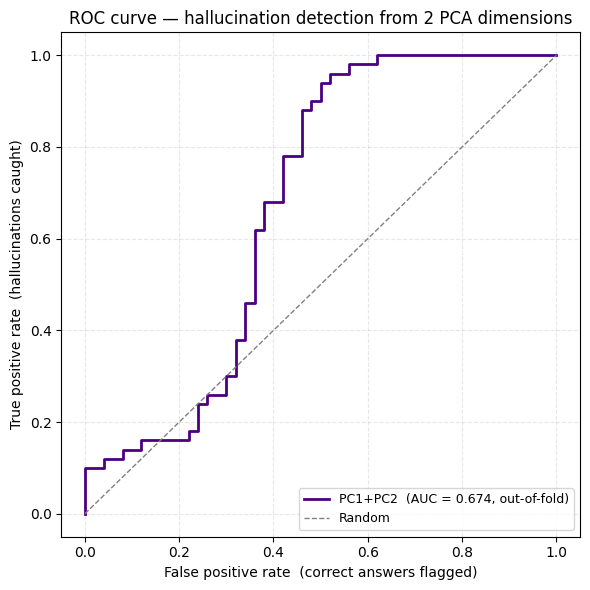

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pca', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg

In [32]:
from sklearn.model_selection import cross_val_predict

pipe_2 = Pipeline([
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# Honest out-of-fold probabilities — PCA fitted inside each fold
y_prob = cross_val_predict(pipe_2, X_raw, y, cv=cv, method="predict_proba")[:, 1]

fpr, tpr, _ = roc_curve(y, y_prob)
auc_oof = roc_auc_score(y, y_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="indigo", linewidth=2,
        label=f"PC1+PC2  (AUC = {auc_oof:.3f}, out-of-fold)")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random")
ax.set_xlabel("False positive rate  (correct answers flagged)")
ax.set_ylabel("True positive rate  (hallucinations caught)")
ax.set_title("ROC curve — hallucination detection from 2 PCA dimensions")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Also fit on full data for the decision-boundary visualisation in Cell 8
pipe_2.fit(X_raw, y)

## Cell 8 — Decision boundary overlaid on PCA scatter

Visualises where the logistic regression draws the line in PC1+PC2 space.
`pipe_2` was fit on all data in Cell 7 **only for this visualisation** — the honest
performance estimate is the out-of-fold AUC from Cells 6 and 7.

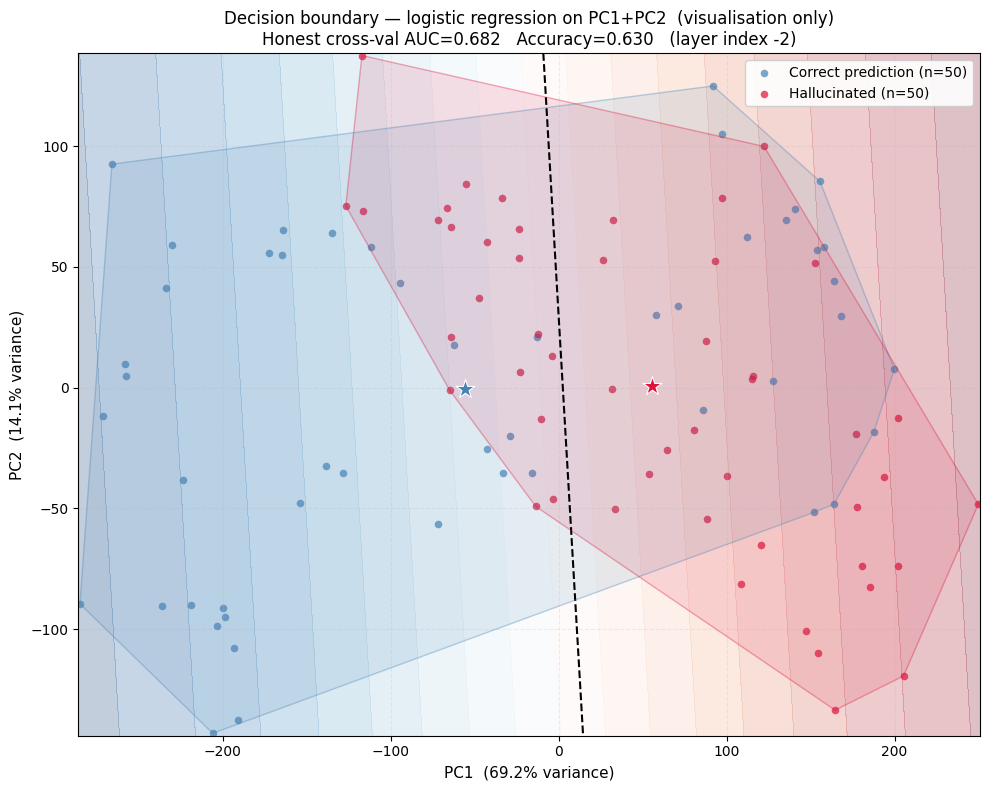

In [33]:
def draw_convex_hull(ax, points, color, alpha=0.12):
    if len(points) < 3:
        return
    try:
        hull = ConvexHull(points)
        vertices = np.append(hull.vertices, hull.vertices[0])
        ax.fill(points[vertices, 0], points[vertices, 1],
                color=color, alpha=alpha, linewidth=0)
        ax.plot(points[vertices, 0], points[vertices, 1],
                color=color, alpha=0.35, linewidth=1)
    except Exception:
        pass

# Use the PCA fitted on all data (inside pipe_2) for projection — visualisation only
pca_viz = pipe_2.named_steps["pca"]   # n_components=2
X_pca_viz = pca_viz.transform(X_raw)

proj_correct      = X_pca_viz[y == 0, :2]
proj_hallucinated = X_pca_viz[y == 1, :2]

x_min, x_max = X_pca_viz[:, 0].min() - 1, X_pca_viz[:, 0].max() + 1
y_min, y_max = X_pca_viz[:, 1].min() - 1, X_pca_viz[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

mesh_raw = pca_viz.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
Z = pipe_2.predict_proba(mesh_raw)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))

ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.25)
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5, linestyles="--")

ax.scatter(proj_correct[:, 0], proj_correct[:, 1],
           c="steelblue", s=30, alpha=0.7, linewidths=0,
           label=f"Correct prediction (n={len(proj_correct)})")
ax.scatter(proj_hallucinated[:, 0], proj_hallucinated[:, 1],
           c="crimson", s=30, alpha=0.7, linewidths=0,
           label=f"Hallucinated (n={len(proj_hallucinated)})")

draw_convex_hull(ax, proj_correct,      "steelblue")
draw_convex_hull(ax, proj_hallucinated, "crimson")

ax.scatter(*proj_correct.mean(axis=0),      c="steelblue", s=200, marker="*",
           zorder=5, edgecolors="white", linewidths=0.8)
ax.scatter(*proj_hallucinated.mean(axis=0), c="crimson",   s=200, marker="*",
           zorder=5, edgecolors="white", linewidths=0.8)

var = pca_viz.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1  ({var[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({var[1]:.1f}% variance)", fontsize=11)
ax.set_title(
    f"Decision boundary — logistic regression on PC1+PC2  (visualisation only)\n"
    f"Honest cross-val AUC={aucs[1]:.3f}   Accuracy={accs[1]:.3f}   (layer index {LAYER_INDEX})",
    fontsize=12,
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()